# Structure of Spheroid Microscopy data

In this section, we will dicuss the structure of the spheroid microscopy images. This is managed in the `SpheroidPy.spheroid` modul. It follows a hierarchical structure, starting from individual (multichannel) images (`SpheroidImage`), from which instances from multiple timepoints can be combined in a timeseries (`SpheroidSeries`), from which then in turn multiple replicates can be combined in a collection (`SpheroidCollection`) for statistical analysis.

If `SpheroidPy` is not installed on your system yet, we have to import its folder to the Python module search path:

In [68]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../SpheroidPy')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## __SpheroidImage:__  Individual (multichannel) Microscope Images

<img src="../docs/source/_images/example_SpheroidImage.png" width="400em" align="right" style="margin-left: 20px; margin-bottom: 20px; margin-top: -20px;" />

The `SpheroidImage` class is the most basic building block of SpheroidPy. It manages the microscopy images of different channels for one measurement of a spheroid. 

After loading the images, they can be segmented using different channels and methods (thresholding or deep learning).

In addition, mathematical calculations that only concern the Image are implemented in this class. For example, different quatifications using fluorescence intensities, radial profiles and even diffusion distributions using differential equations can be calculated using this class.


#### __Creating a `SpheroidImage`:__
We start by importing the class

In [8]:
from SpheroidPy.spheroid import SpheroidImage

Information on what the class does and what parameters we need as input can be seen by typing

In [ ]:
SpheroidImage?

So now we can create a Spheroid based on a brightfield/phase contrast image and optionally fluorescence images

In [70]:
# specify the paths of your Images
path_pc='example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_C5_1_2025y05m20d_18h00m.tif'          #PhaseContrast
path_green='example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_C5_1_2025y05m20d_18h00m.tif'  #green Fluorescence
path_red='example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_C5_1_2025y05m20d_18h00m.tif'        #red Fluorescence

# create a SpheroidImage
my_spheroid = SpheroidImage(brightfield = path_pc, fluorescence_green = path_green, fluorescence_red = path_red, #paths
                           image_size = (1700,1270)) # size of image in x- and y-direction [µm]

We can test the images to see if everything worked and the Spheroid has been created successfully

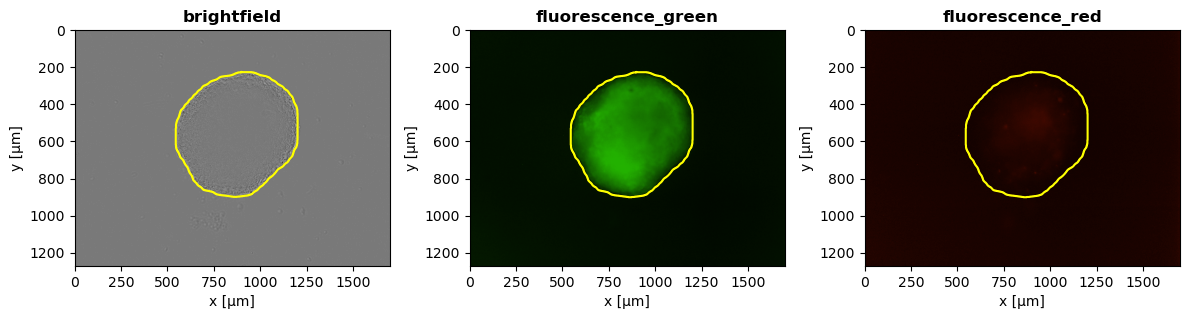

In [78]:
my_spheroid.show()

#### __Basic Usage:__
Now that we are familiar with the creation of SpheroidImages, we can start extracting some valueable information out of it. As for that we almost always need to know the exact boundary of the spheroid first, we start by segmenting the spheroid. For that two methods have been implemented:
1. Thresholding: ... (usually based on fluorescence color expressed in all cells)
2. Deep learning: ... (most useful for brightfield/phase contrast or similar fluorescence as before)
3. Manual:

In [76]:
my_spheroid.segmentation_detectron('brightfield', thres=.8)

array([[735., 185.],
       [734., 186.],
       [724., 186.],
       ...,
       [787., 186.],
       [782., 186.],
       [781., 185.]], dtype=float32)

In [199]:
my_spheroid.segmentation_thresholding('fluorescence_green', 1.4)

array([[1012. , 1034.5],
       [1011. , 1034.5],
       [1010. , 1034.5],
       ...,
       [1012.5, 1033. ],
       [1012.5, 1034. ],
       [1012. , 1034.5]], dtype=float32)

`segmentation()` method also prvides border reconstruction

In [12]:
my_spheroid.segmentation(border_margin=10)

Text

In [13]:
my_spheroid.segmentation_manual('brightfield')

The result can be überprüft with

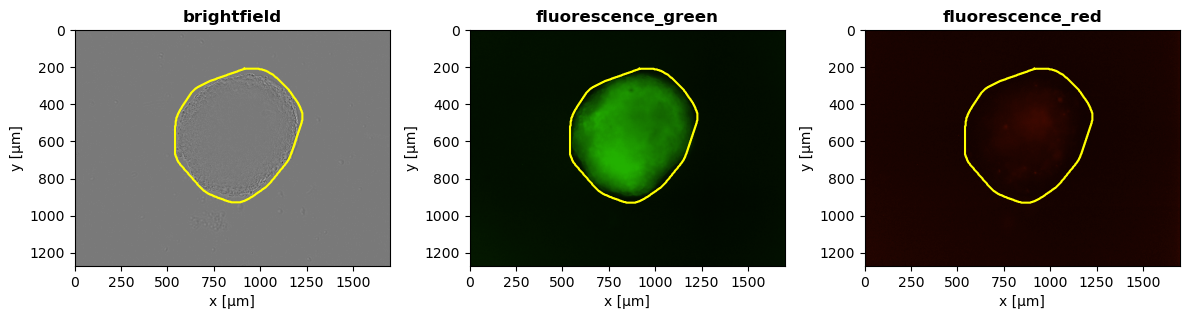

In [15]:
my_spheroid.show()

In [246]:
my_spheroid.contour_touches_border

False

In [17]:
my_spheroid.radius, my_spheroid.area, my_spheroid.metric_fluorescence('green')

(341.5640612523049, 366517.0734653396, (16877266, 68.45927878959964))

#### __Advanced Usage:__
After performing the segmentation, it is also possible to get more advanced information from the provided images. 
This section aims to give an overview over some examples for that.


__Radial Profiles:__
Text

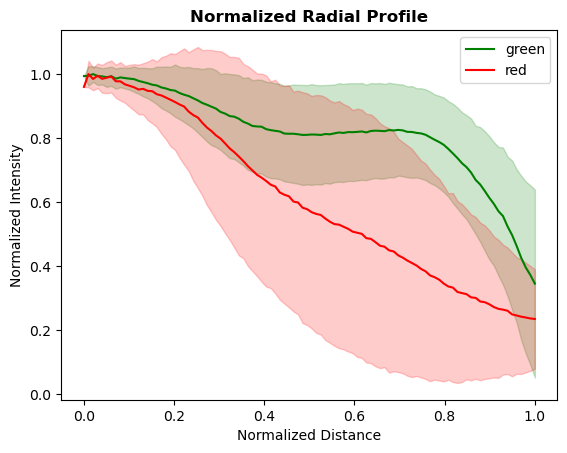

{'mean_radius': 368.854602565547,
 'intensity_profiles': {'green': {'mean': array([0.99388268, 0.99446886, 1.        , 0.9940663 , 0.99276618,
          0.99022203, 0.99330786, 0.98575837, 0.98963223, 0.98750163,
          0.9857627 , 0.9842498 , 0.97872474, 0.97507561, 0.97143615,
          0.96679038, 0.96459531, 0.95823528, 0.95508195, 0.95015965,
          0.94831124, 0.94077461, 0.93550215, 0.93140242, 0.92455111,
          0.91773908, 0.90963222, 0.90424869, 0.8980972 , 0.89204628,
          0.881654  , 0.87653379, 0.86877377, 0.86697288, 0.86060517,
          0.85091055, 0.84537366, 0.83784527, 0.83642062, 0.83563865,
          0.82801457, 0.8248662 , 0.82276829, 0.82067426, 0.81421107,
          0.8136085 , 0.81372487, 0.81197651, 0.80988905, 0.81025851,
          0.81131939, 0.81088076, 0.809892  , 0.81283071, 0.81186284,
          0.81494883, 0.81760194, 0.81614038, 0.81881987, 0.81856381,
          0.81945747, 0.82083992, 0.81771478, 0.82231067, 0.82326609,
          0.82260

In [102]:
my_spheroid.radial_profile(channels=['green', 'red'], plot=True, angle_step=2)

In [82]:
my_spheroid.radius

329.33959304888737

__Diffusion Distribution:__
Text

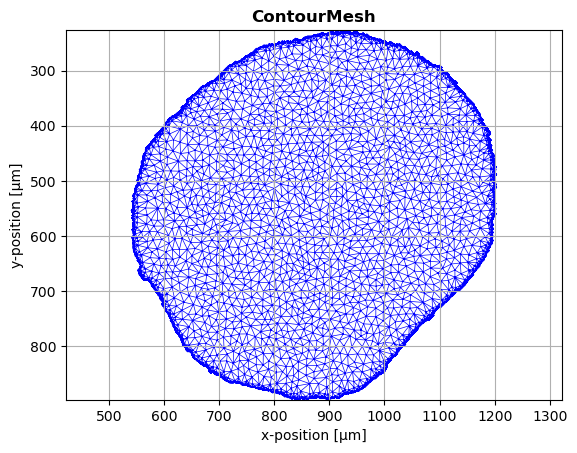

(array([[692.        , 734.5       ],
        [691.        , 734.5       ],
        [690.5       , 734.        ],
        ...,
        [578.59399201, 431.20183265],
        [526.60325609, 355.48232023],
        [569.15034666, 380.38310746]]),
 array([[ 830, 2616, 3071],
        [2124, 3512, 3062],
        [ 826,  827, 2617],
        ...,
        [5259, 5860, 4630],
        [5828, 5861, 4790],
        [4860, 5861, 4827]]))

In [111]:
my_spheroid.mesh(max_area=100)

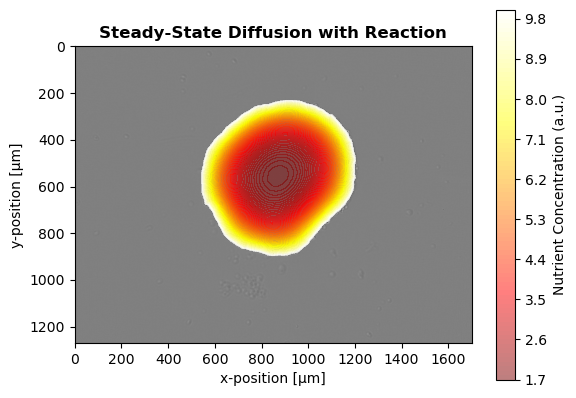

(array([[692.        , 734.5       ],
        [678.5       , 732.        ],
        [666.        , 726.5       ],
        ...,
        [558.08610252, 665.06900169],
        [712.1774571 , 411.01106806],
        [707.46834051, 395.24444766]]),
 array([[475,  39,  40],
        [152, 103, 171],
        [475,  41, 260],
        ...,
        [518, 660, 513],
        [426, 661, 408],
        [427, 661, 428]]),
 array([10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        10.        , 10.        , 10.        , 10.        , 10.        ,
        

In [127]:
my_spheroid.diffusion_stationary(
    boundary_value = 10,
    diffusion_rate = 2000,
    reaction_rate = .1,
    plot = True,
    accuracy = 20)

## __SpheroidSeries:__ Timeseries of multiple SpheroidImages
<img src="../docs/source/_images/example_SpheroidSeries.png" width="400em" align="right" style="margin-left: 20px; margin-bottom: 30px; margin-top: -30px;" />

In Experiments it often is necessary to observe a spheroid over a longer period for different timepoints. 
To simplify the data handling of such processes, multiple `SpheroidImage` instances of the same spheroid at different timepoints can be combined into one `SpheroidSeries`. 
This allows for the management of time-lapse microscopy data and investigation of the evolution of the spheroid over time.

#### __Creating `SpheroidSeries`:__
Similarly, first an instance of the `SpheroidSeries` class has to initiated. Afterwards multiple `SpheroidImage` instances can be added.
In our case we take a look at the previous Spheroid from Well C5 for which we have images taken after every 48h.


In [84]:
from SpheroidPy.spheroid import SpheroidSeries, SpheroidImage    # import of the class
from datetime import datetime                     # module for timepoints

spheroid_series = SpheroidSeries('My SpheroidSeries Name')

In [86]:
# creating and adding SpheroidImages for every 48h
for day in range(10,26,2):
    # timepoint of image
    date_time = datetime.strptime(f'2025y05m{day}d_18h00m', '%Yy%mm%dd_%Hh%Mm')
    # path of the image channels
    path_pc=f'example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_C5_1_2025y05m{day}d_18h00m.tif'          #PhaseContrast
    path_green=f'example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_C5_1_2025y05m{day}d_18h00m.tif'  #green Fluorescence
    path_red=f'example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_C5_1_2025y05m{day}d_18h00m.tif'        #red Fluorescence

    # create a SpheroidImage
    my_spheroid = SpheroidImage(brightfield = path_pc, fluorescence_green = path_green, fluorescence_red = path_red, image_size = (1700,1270))
    # add to SpheroidSeries
    spheroid_series.add_spheroid_image(my_spheroid, date_time)

We can now visualise our Series using an interactive build-in method:

In [92]:
spheroid_series.show()

#### __Basic Usage:__
In a next step, the images have to be segmented first in order to identify the evolution of the spheroids over time. This can be done in a similar way is previously

In [90]:
spheroid_series.segmentation(methods=[('thresholding', 'fluorescence_green'),('ai', 'brightfield')], threshold=1.2, border_margin=7)

Segmentation finished: 8/8 images segmented successfully.


Afterwards the segmentation can be überprüft using the `show()` method or by ...

There are currently the following metrics available
- based on contour: 'radius', 'area'
- based on fluorescence intensity: 'fluorescence_(color)_ cumulative' or 'fluorescence_(color)_mean'


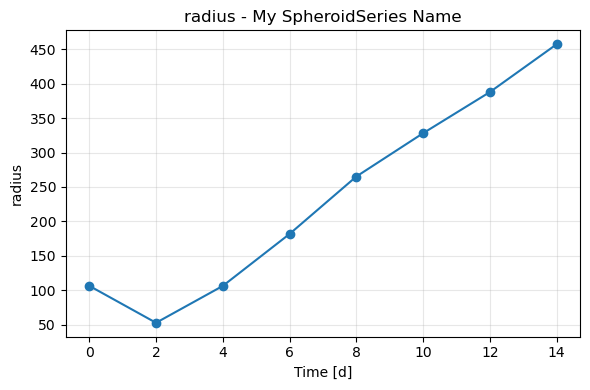

In [96]:
spheroid_series.metric('radius', plot=True).to_excel('test123.xlsx')

If it is desired to restrict the investigation to certain time peroids during the experiment, this can be done using the `TimePeroid` class which manages ... and is embedded into the `SpheroidSeries` class via the following method

In [16]:
spheroid_series.time_period('Proliferation', start_time='2025-05-14 18:00:00', end_time='2025-05-24 18:00:00')

TimePeriod(name='Proliferation', start=2025-05-14 18:00:00, end=2025-05-24 18:00:00)

##### __Exporting Videos:__
The resulting figures can be saved locally. In addition, videos of both inidivual channels as well as overlay of several ... can be exported for visualisation purposes.

In [14]:
spheroid_series.export_video?

Signature:
spheroid_series.export_video(
    channel: str = 'brightfield',
    overlay_channels: list[str] = [],
    increases: list[str] = [],
    video_name: str = 'test.mp4',
    scalebar: bool = True,
    fps: int = 5,
    contour: bool = True,
    time: bool = True,
    exclude_out_of_contour: bool = True,
    diffusion_dict: dict = {},
)
Docstring:
Exports the spheroid series images to a video.

:param parent_folder:
:param channel: Channel to export (default: brightfield)
:param overlay: other channels/contours/fields, that get overlayed (default: none)
:param format: format of the video (default: ???)
:return:
File:      ~/Documents/Labor/SpheroidPy/SpheroidPy/spheroid/spheroid_series.py
Type:      method

##### __Custom Analysis:__

Text

## __SpheroidCollection:__ Managing Sets of multiple SpheroidSeries
<img src="../docs/source/_images/example_SpheroidCollection.png" width="500em" align="right" style="margin-left: 50px; margin-bottom: 25px; margin-top: 10px;" />

If there are available multiple replicates, i.e. in a technical or biological sense, it often proves useful being able to combine them into one instance, so that (statistical) analyses can be streamlined and measures easily compared for different `SpheroidSeries`. Therefore, it is possible to merge multiple `SpheroidSeries` into one instance of the `SpheroidCollection`.

#### __Creating `SpheroidCollection`:__
In the following example we show this for three technical replicate Wells B5, C5, D5, which have been seeded under the same conditions and have been recorded at the same timepoints. First we have to  create `SpheroidSeries` for the three wells - similarly as shown before - and save them in an empty list:

In [100]:
spheroidseries_list = []
for well_name in ['B5', 'C5', 'D5']:
    spheroid_series = SpheroidSeries(name=f'Well {well_name}')
    
    for day in range(10,26,2):
        date_time = datetime.strptime(f'2025y05m{day}d_18h00m', '%Yy%mm%dd_%Hh%Mm')
        path_pc=f'example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_{well_name}_1_2025y05m{day}d_18h00m.tif'          #PhaseContrast
        path_green=f'example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_{well_name}_1_2025y05m{day}d_18h00m.tif'  #green Fluorescence
        path_red=f'example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_{well_name}_1_2025y05m{day}d_18h00m.tif'        #red Fluorescence

        # create a SpheroidImage and add to SpheroidSeries
        my_spheroid = SpheroidImage(brightfield = path_pc, 
                                    fluorescence_green = path_green, 
                                    fluorescence_red = path_red, 
                                    image_size = (1700,1270))
        spheroid_series.add_spheroid_image(my_spheroid, date_time)
        
    spheroidseries_list.append(spheroid_series) # add to our list

Now we can specify a `SpheroidCollection` based on our list of `SpheroidSeries` objects

In [103]:
from SpheroidPy.spheroid import SpheroidCollection, SpheroidSeries, SpheroidImage   # import the class
spheroid_collection = SpheroidCollection(name='HCT116_800K_cells', spheroid_list=spheroidseries_list)

TODO: Visualise `SpheroidCollection` similar to Series

In [105]:
spheroid_collection.show()

#### __Basic Usage:__
Text

In [57]:
spheroid_collection.segmentation(methods=[('thresholding', 'fluorescence_green'),('ai', 'brightfield')], border_margin=)

Processing segmentation: 100%|██████████| 3/3 [00:11<00:00,  3.72s/it]


Segmentation complete for collection 'HCT116_800K_cells':
Successfully segmented 23/23 images across 3 series


In [63]:
spheroid_collection.metric()

,Well B5,Well C5,Well D5
0.0,4.871919,106.395404,170.938430
48.0,52.614475,47.202338,181.593895
96.0,106.628277,101.629454,171.851046
144.0,179.020999,178.796789,175.692656
192.0,259.655025,262.480736,275.780336
240.0,327.111208,326.208025,334.834871
288.0,395.637357,385.515390,352.744798
336.0,396.319321,409.638916,370.654726
